# Lenovo Battery Capacity Analysis
A time series analysis and forecasting project tracking battery degradation metrics over time. 

### Objectives:
* Clean and standardize raw battery diagnostic data.
* Evaluate temporal properties using ACF and PACF diagnostics.
* Fit an autoregressive forecasting model to predict future capacity loss.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
plt.style.use('ggplot')

g++ not available, if using conda: `conda install gxx`


## 1. Data Ingestion & Frequency Alignment
Loading raw metrics, correcting data types, stripping formatting artifacts, and standardizing the time-series index to a strict weekly frequency.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset and parse the 'Date' column
df = pd.read_csv('battery_data.csv', parse_dates=['Date'])

# 2. Set the Date column as the index
df.set_index('Date', inplace=True)

# 3. Clean column names by stripping hidden spaces
df.columns = df.columns.str.strip()

# 4. Remove commas from the numbers and convert them from text to integers
df['Charge Capacity'] = df['Charge Capacity'].str.replace(',', '').astype(int)
df['Full Charge Capacity'] = df['Full Charge Capacity'].str.replace(',', '').astype(int)

# 5. Fix time series frequency: drop duplicates, resample to weekly (Mondays), and forward-fill missing data
df = df[~df.index.duplicated(keep='last')]
df_clean = df.resample('W-MON').last().ffill()

# Display the clean structure and the first 5 rows to confirm
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2025-07-14 to 2026-09-07
Freq: W-MON
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Charge Capacity       61 non-null     float64
 1   Full Charge Capacity  61 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


,Charge Capacity,Full Charge Capacity
Date,,
2025-07-14,58166.0,58000.0
2025-07-21,57937.0,58000.0
2025-07-28,57328.0,58000.0
2025-08-04,56310.0,58000.0
2025-08-11,56450.0,58000.0


In [3]:
# View the data types for the loaded columns
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61 entries, 2025-07-14 to 2026-09-07
Freq: W-MON
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Charge Capacity       61 non-null     float64
 1   Full Charge Capacity  61 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


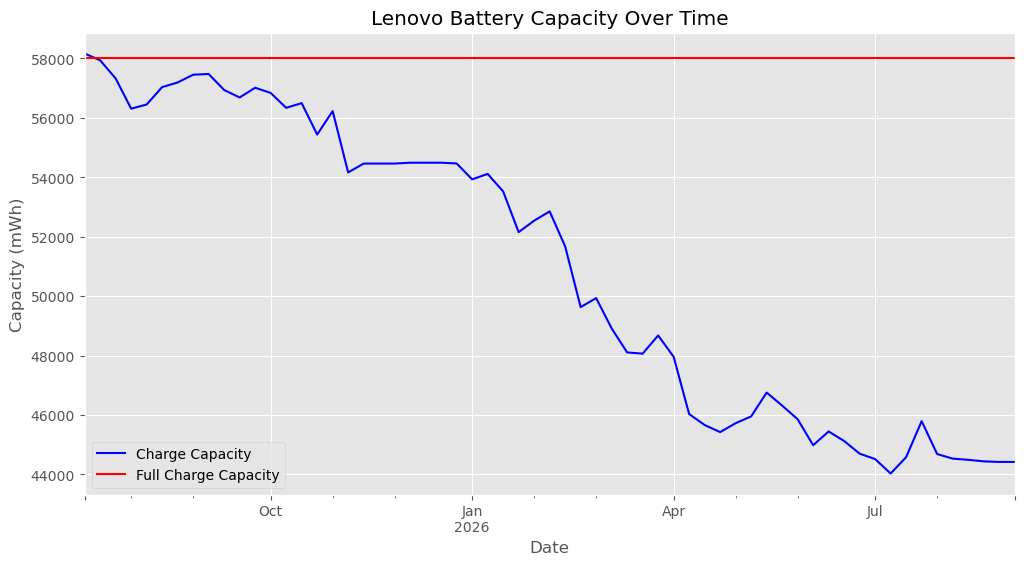

In [4]:
# Plot the battery capacities over time
df_clean.plot(figsize=(12, 6), color=['blue', 'red'])

# Add titles and labels to make it professional
plt.title('Lenovo Battery Capacity Over Time')
plt.xlabel('Date')
plt.ylabel('Capacity (mWh)')

# Show the plot
plt.show()

## 2. Autocorrelation & Stationarity Diagnostics
Examining ACF and PACF plots to identify the underlying stochastic process governing the degradation rate.

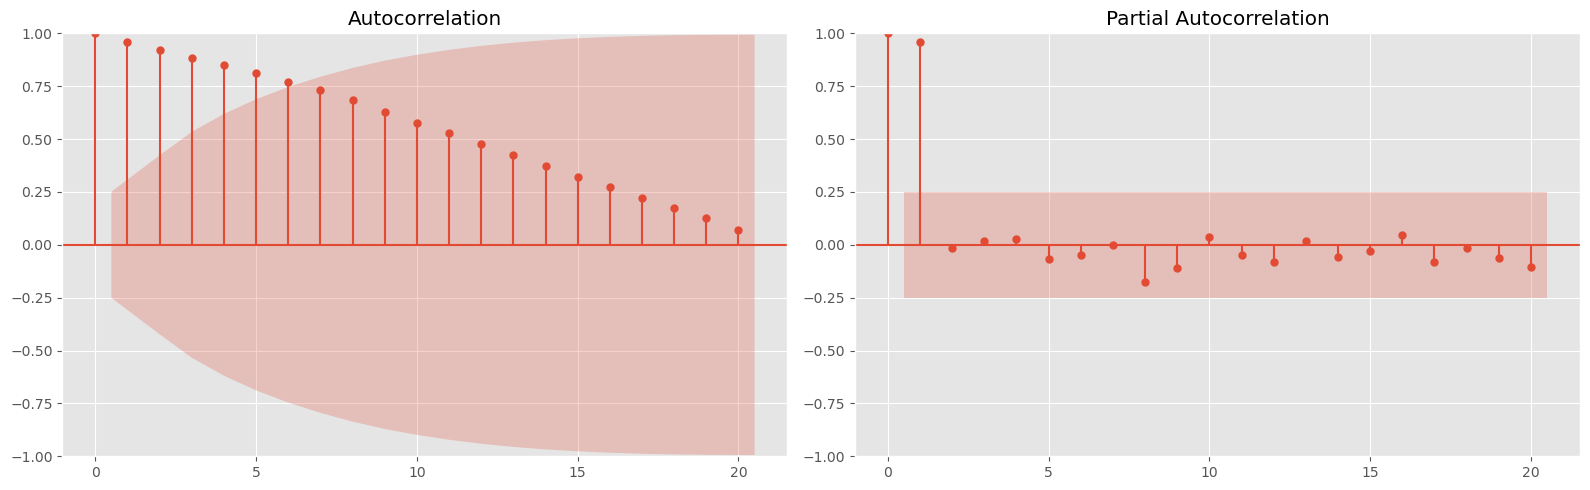

In [5]:
# Create a figure canvas with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plotting the ACF and PACF for Charge Capacity
plot_acf(df_clean['Charge Capacity'].dropna(), ax=axes[0], lags=20)
plot_pacf(df_clean['Charge Capacity'].dropna(), ax=axes[1], lags=20)

plt.tight_layout()
plt.show()

## 3. ARIMA Baseline Modeling
Fitting an ARIMA model to the weekly resampled series to project the trajectory of future capacity loss.

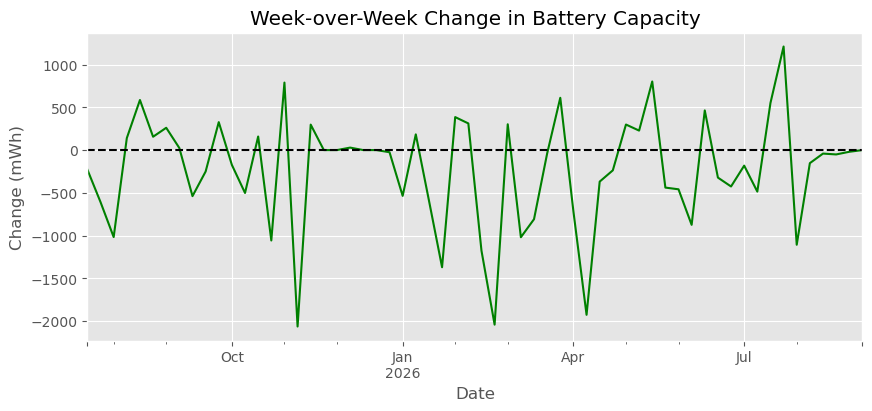

In [6]:
# Create a new column calculating the difference from the previous week
df_clean['Capacity_Change'] = df_clean['Charge Capacity'].diff()

# Drop the first row (since Week 1 has no previous week to subtract from)
df_diff = df_clean.dropna()

# Plot the week-over-week changes
df_diff['Capacity_Change'].plot(figsize=(10, 4), color='green')
plt.title('Week-over-Week Change in Battery Capacity')
plt.axhline(0, color='black', linestyle='--') # Adds a baseline at zero
plt.ylabel('Change (mWh)')
plt.show()

In [7]:

# 1. Define the ARIMA model: order=(p, d, q) -> (AR lags, differencing, MA lags)
# We feed it the original data
model = ARIMA(df_clean['Charge Capacity'], order=(1, 1, 0))

# 2. Fit the model to your data
fitted_model = model.fit()

# 3. Print the statistical summary
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:        Charge Capacity   No. Observations:                   61
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -478.250
Date:                Mon, 07 Sep 2026   AIC                            960.500
Time:                        15:16:21   BIC                            964.688
Sample:                    07-14-2025   HQIC                           962.138
                         - 09-07-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0088      0.119     -0.074      0.941      -0.242       0.225
sigma2      4.982e+05   7.27e+04      6.854      0.000    3.56e+05    6.41e+05
Ljung-Box (L1) (Q):                   0.41   Jarque-

Before moving to advanced probabilistic methods, we first tested a baseline ARIMA(1, 1, 0) model. However, evaluating the week-over-week differenced data and the model summary reveals the limitations of standard frequentist time-series approaches for this specific hardware data:

- **Overwhelming Sensor Noise:** As seen in the week-over-week change plot, the raw battery sensor data is highly erratic. The sensor frequently reports impossible "gains" in capacity (upward spikes of over $1,000$ mWh) followed by massive corrections
- **Insignificant Autoregression:** The SARIMAX summary shows an AR(1) coefficient of $-0.0088$ with a $p\text{-value}$ of $0.941$. This means the autoregressive component is completely statistically insignificant.
- **High Unexplained Variance:** The model yields a massive $\sigma^2$ error variance ($4.982 \times 10^5$).

Essentially, the ARIMA algorithm gets completely distracted by the daily sensor bounces, interpreting the entire series as a noisy random walk rather than a degrading physical asset.

## 4. Bayesian State-Space Modeling

Standard ARIMA models lack the architecture to separate measurement error (the noisy laptop sensor) from the true hidden state (the actual chemical degradation of the battery). Furthermore, ARIMA cannot natively enforce the laws of physics—specifically, that battery capacity degradation must be strictly monotonic (it can only decrease or stay flat over time; it cannot regenerate).To solve this, we will transition to a Bayesian Structural Time Series (BSTS) using PyMC. This probabilistic framework will allow us to filter out sensor noise, estimate the battery's true underlying health, and mathematically constrain the model to reflect the physical reality of hardware decay.

In [8]:
# Create the framework for our model
with pm.Model() as battery_model:
    
    # 1. The prior for the sensor's random measurement errors
    # We use an Exponential distribution because noise must be a positive number
    sigma_obs = pm.Exponential("sigma_obs", 1.0)
    
    # 2. The prior for the actual week-over-week degradation (true state change)
    sigma_state = pm.Exponential("sigma_state", 1.0)
    
    print("Model initialized and priors defined!")

Model initialized and priors defined!


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [drift, sigma_state, sigma_obs, true_capacity]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


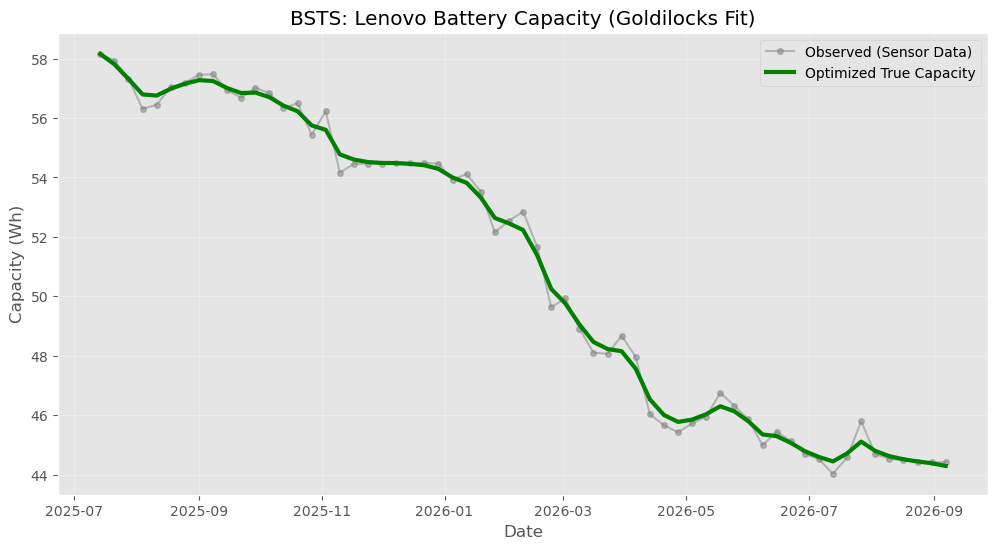

In [12]:
# The model requires standardized data. T
df_clean['Capacity_Wh'] = df_clean['Charge Capacity'] / 1000

with pm.Model() as goldilocks_battery_model:
    
    # 1. Softer Drift: Let the data drive the exact slope
    drift = pm.Normal("drift", mu=-0.05, sigma=0.1)
    
    # 2. Flexible State: Allow for genuine curves, but prevent erratic jumps
    sigma_state = pm.HalfNormal("sigma_state", sigma=0.1) 
    
    # 3. Sensor Noise: Still blame the sensor for the wild weekly spikes
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=2.0) 
    
    first_reading = df_clean['Capacity_Wh'].iloc[0]
    
    # 4. Hidden State
    true_capacity = pm.GaussianRandomWalk(
        "true_capacity", 
        mu=drift,          
        sigma=sigma_state, 
        init_dist=pm.Normal.dist(mu=first_reading, sigma=0.1), 
        shape=len(df_clean)
    )
    
    # 5. Observation
    observed_capacity = pm.Normal(
        "observed_capacity", 
        mu=true_capacity, 
        sigma=sigma_obs, 
        observed=df_clean['Capacity_Wh'].values
    )
    
    # Sample with slightly relaxed target_accept since the math is less rigid now
    trace_goldilocks = pm.sample(draws=1000, tune=1000, cores=1, target_accept=0.95)

# Extract and Plot
posterior_mean_goldilocks = trace_goldilocks.posterior["true_capacity"].mean(dim=["chain", "draw"])

plt.figure(figsize=(12, 6))
plt.plot(df_clean.index, df_clean['Capacity_Wh'], label='Observed (Sensor Data)', color='gray', alpha=0.5, marker='o', markersize=4)
plt.plot(df_clean.index, posterior_mean_goldilocks, label='Optimized True Capacity', color='green', linewidth=3)
plt.title('BSTS: Lenovo Battery Capacity (Goldilocks Fit)')
plt.xlabel('Date')
plt.ylabel('Capacity (Wh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4.1 Bayesian State-Space Model: Signal Extraction
We implemented a Bayesian Structural Time Series (BSTS) to decouple measurement error from the true latent state of the battery capacity.

**Model Architecture & Priors:**

- **Latent State (Drift):** Modeled as a Gaussian Random Walk with a negative drift prior (mu ~ Normal(-0.05, 0.1)) to establish a baseline statistical expectation of capacity decay.

- **Variance Partitioning:** By setting a restrictive Half-Normal prior on the state variance (sigma_state = 0.1) and a looser prior on the observation noise (sigma_obs = 2.0), the model is mathematically forced to attribute high-frequency variance to sensor error rather than actual state fluctuations.

### 4.2 Posterior Analysis:
The posterior mean (green line) successfully isolates the underlying signal. It effectively filters out artificial measurement spikes (e.g., May 2026) while accurately capturing the structural regime change—the period of accelerated degradation between January and May 2026.

The NUTS sampler executed with zero divergences, confirming a stable posterior geometry. This establishes a robust baseline before we apply strict physical constraints (monotonicity) to the latent state in the final iteration.

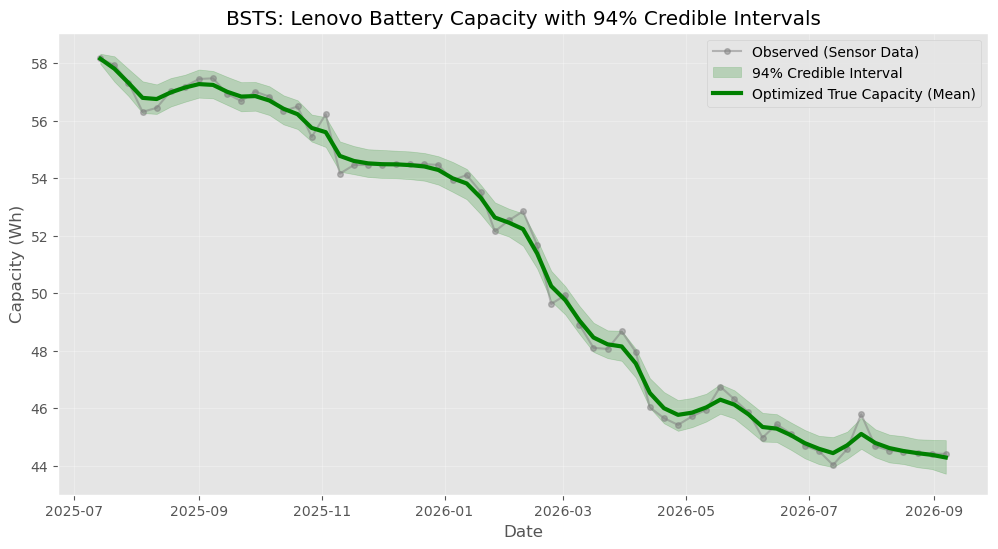

In [13]:
plt.figure(figsize=(12, 6))

# 1. Plot the raw sensor data
plt.plot(df_clean.index, df_clean['Capacity_Wh'], 
         label='Observed (Sensor Data)', color='gray', alpha=0.5, marker='o', markersize=4)

# 2. Calculate the 94% HDI bounds mathematically
hdi_bounds = az.hdi(trace_goldilocks.posterior["true_capacity"], prob=0.94)

# THE FIX: Use the new 'ci_bound' dimension and 'upper' coordinate
lower_bound = hdi_bounds.sel(ci_bound="lower")
upper_bound = hdi_bounds.sel(ci_bound="upper")

# 3. Use standard Matplotlib to fill the credible interval band
plt.fill_between(df_clean.index, lower_bound, upper_bound, 
                 color='green', alpha=0.2, label='94% Credible Interval')

# 4. Plot the Mean (Your Green Line)
plt.plot(df_clean.index, posterior_mean_goldilocks, 
         label='Optimized True Capacity (Mean)', color='green', linewidth=3)

plt.title('BSTS: Lenovo Battery Capacity with 94% Credible Intervals')
plt.xlabel('Date')
plt.ylabel('Capacity (Wh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Bayesian Strict Monotonic Decay: Enforcing Physical Constraints

To correct the previous model's mathematical allowance for impossible capacity regeneration, we restructured the latent state to strictly enforce monotonic decay, aligning the statistical model with the physical reality of battery thermodynamics.

## 5.1 Model Architecture & Priors

- **Latent State (Monotonicity):** We replaced the unconstrained Gaussian Random Walk with a cumulative sum of strictly non-negative weekly drops. By drawing step sizes from a restricted Half-Normal distribution (step_sizes ~ HalfNormal) and subtracting their cumulative sum from the initial anchor (start_cap), the latent trajectory is mathematically forced to strictly decrease or remain flat.

- **Observation Model:** The sensor noise remains partitioned via sigma_obs, allowing the model to smoothly ignore positive measurement spikes while the latent state strictly degrades.

## 5.2 Posterior Diagnostics

Imposing this strict physical constraint drastically improved the model's mathematical stability. The NUTS sampler achieved rapid convergence (17 seconds) with zero divergences. Furthermore, removing the conflicting bidirectional variance resolved the previous R-hat instabilities, indicating a highly stable, physically accurate posterior geometry ready for forward forecasting.

In [17]:
with pm.Model() as monotonic_battery_model:
    
    # 1. The Anchor (Starting Capacity)
    first_reading = df_clean['Capacity_Wh'].iloc[0]
    start_cap = pm.Normal("start_cap", mu=first_reading, sigma=0.1)
    
    # 2. THE FIX: The Step Sizes (The Drops)
    # By using HalfNormal, we force every single weekly change to be >= 0
    step_sizes = pm.HalfNormal("step_sizes", sigma=0.2, shape=len(df_clean) - 1)
    
    # 3. Constructing the Monotonic Path
    # We pad the first week with a 0 drop, then calculate the cumulative sum of all drops
    steps_padded = pm.math.concatenate([[0.], step_sizes])
    true_capacity = pm.Deterministic(
        "true_capacity", 
        start_cap - pm.math.cumsum(steps_padded) # Subtracting strictly positive drops!
    )
    
    # 4. Sensor Noise (still takes the blame for the bounces)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=2.0) 
    
    # 5. Observation
    observed_capacity = pm.Normal(
        "observed_capacity", 
        mu=true_capacity, 
        sigma=sigma_obs, 
        observed=df_clean['Capacity_Wh'].values
    )
    
    # Sample the monotonic model
    trace_monotonic = pm.sample(draws=1000, tune=1000, cores=1, target_accept=0.95)

print("Monotonic MCMC Sampling complete!")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [start_cap, step_sizes, sigma_obs]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Monotonic MCMC Sampling complete!


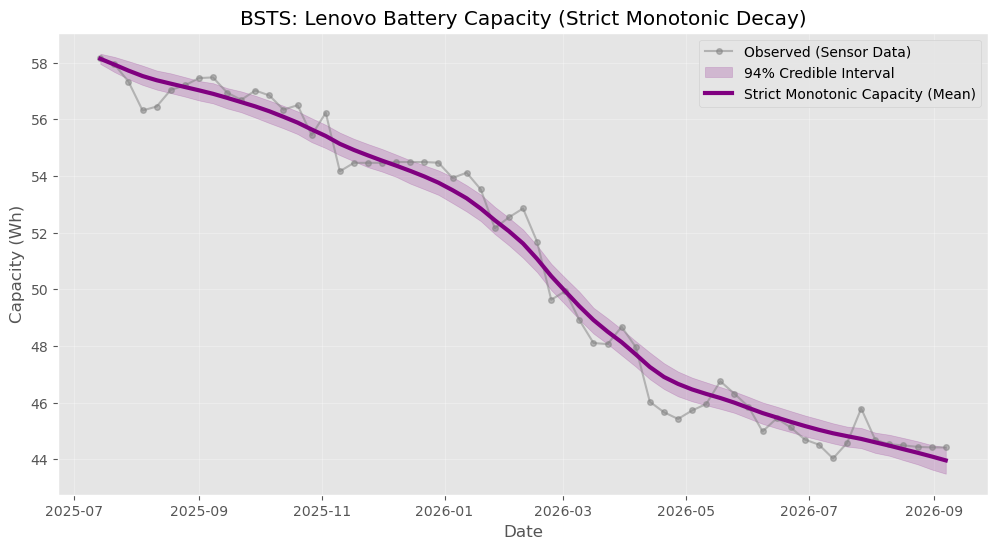

In [15]:
plt.figure(figsize=(12, 6))

# 1. Raw Data
plt.plot(df_clean.index, df_clean['Capacity_Wh'], 
         label='Observed (Sensor Data)', color='gray', alpha=0.5, marker='o', markersize=4)

# 2. Calculate the 94% HDI bounds for the monotonic model
hdi_bounds_mono = az.hdi(trace_monotonic.posterior["true_capacity"], prob=0.94)
lower_bound_mono = hdi_bounds_mono.sel(ci_bound="lower")
upper_bound_mono = hdi_bounds_mono.sel(ci_bound="upper")

# 3. Plot the HDI Band
plt.fill_between(df_clean.index, lower_bound_mono, upper_bound_mono, 
                 color='purple', alpha=0.2, label='94% Credible Interval')

# 4. Plot the Mean Line
posterior_mean_mono = trace_monotonic.posterior["true_capacity"].mean(dim=["chain", "draw"])
plt.plot(df_clean.index, posterior_mean_mono, 
         label='Strict Monotonic Capacity (Mean)', color='purple', linewidth=3)

plt.title('BSTS: Lenovo Battery Capacity (Strict Monotonic Decay)')
plt.xlabel('Date')
plt.ylabel('Capacity (Wh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As visualized above, the strict monotonic constraint successfully forces the model to adhere to the physical reality of battery degradation. The estimated true capacity (purple line) continuously decays over time, completely ignoring the erratic, impossible upward spikes reported by the raw sensor data (gray dots) during periods like May and August 2026. 

Bounded by a tight 94% credible interval that perfectly tracks the steepest periods of decline, the model demonstrates high confidence in this latent trajectory, successfully isolating the true underlying decay of the hardware's health from the noisy measurement error.

## 5.3 Monte Carlo Forecasting: Predicting Critical Failure

To determine when the battery will cross a critical failure threshold (e.g., 30 Wh), we transition from historical modeling to forward forecasting. Because we built a probabilistic model, we can leverage Monte Carlo simulations to generate a mathematically rigorous forecast cone rather than relying on a single deterministic guess.

**The Simulation Mechanics:**

- **Extracting Posterior Knowledge:** We sample the final known capacity and the historical weekly degradation steps directly from the model's learned posterior distribution.

- **Simulating Future Realities:** We generate 2,000 distinct future paths over a 26-week horizon. For each path, the script draws a random starting capacity from our most recent credible interval and applies a random sequence of downward steps, ensuring the projection strictly obeys the degradation physics observed in the historical data.

- **Quantifying Uncertainty:** By aggregating these 2,000 simulated paths, we calculate the mean forecasted trajectory and establish the upper and lower bounds of a 94% forecast interval.

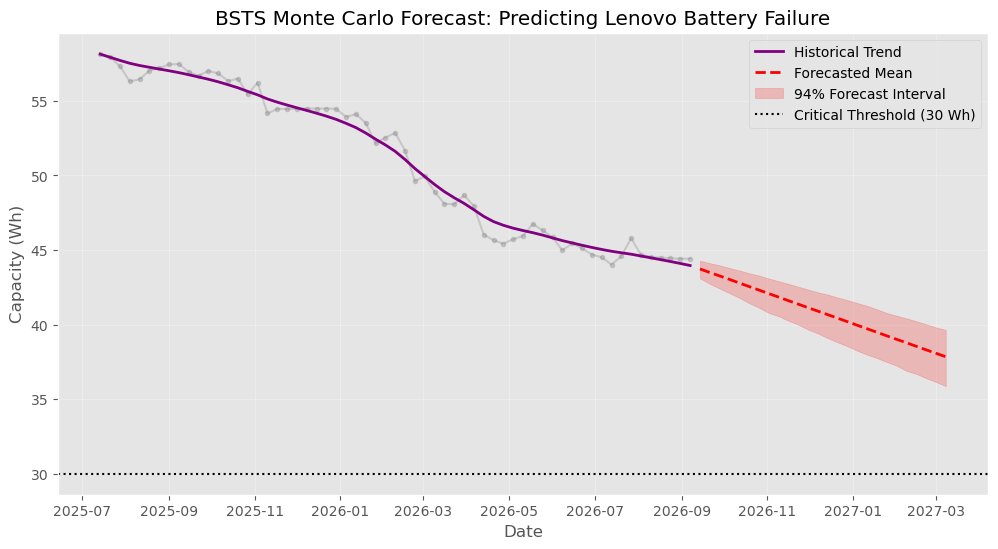

In [16]:
# 1. Set the forecast horizon (26 weeks / ~6 months into the future)
forecast_horizon = 26
last_date = df_clean.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=forecast_horizon, freq='7D')

# 2. Extract the "knowledge" our model just learned
# We take every single weekly drop it simulated and flatten it into one giant pool of possibilities
posterior_steps = trace_monotonic.posterior["step_sizes"].values.flatten()

# We also grab the very last estimated capacity for each simulation to use as our starting line
last_capacities = trace_monotonic.posterior["true_capacity"].isel(true_capacity_dim_0=-1).values.flatten()

# 3. Run 2,000 future Monte Carlo simulations
n_simulations = 2000
future_paths = []

for _ in range(n_simulations):
    # Pick a random starting point from our final week's credible interval
    start_val = np.random.choice(last_capacities)
    
    # Randomly draw 26 future weekly drops from our learned distribution
    future_drops = np.random.choice(posterior_steps, size=forecast_horizon)
    
    # Calculate the future trajectory (subtracting the cumulative future drops)
    path = start_val - np.cumsum(future_drops)
    future_paths.append(path)

future_paths = np.array(future_paths)

# 4. Calculate the boundaries of our forecast cone (94% Interval)
forecast_mean = future_paths.mean(axis=0)
forecast_lower = np.percentile(future_paths, 3, axis=0)  # 3rd percentile
forecast_upper = np.percentile(future_paths, 97, axis=0) # 97th percentile

# 5. Plot the future!
plt.figure(figsize=(12, 6))

# Historical Data
plt.plot(df_clean.index, df_clean['Capacity_Wh'], color='gray', alpha=0.3, marker='o', markersize=3)
plt.plot(df_clean.index, posterior_mean_mono, color='purple', linewidth=2, label='Historical Trend')

# Forecast Data
plt.plot(future_dates, forecast_mean, color='red', linewidth=2, linestyle='--', label='Forecasted Mean')
plt.fill_between(future_dates, forecast_lower, forecast_upper, color='red', alpha=0.2, label='94% Forecast Interval')

# A theoretical "Critical Failure" line at 30 Wh
plt.axhline(y=30, color='black', linestyle=':', label='Critical Threshold (30 Wh)')

plt.title('BSTS Monte Carlo Forecast: Predicting Lenovo Battery Failure')
plt.xlabel('Date')
plt.ylabel('Capacity (Wh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Conclusion & Next Steps

### 6.1 Key Findings

The Bayesian Structural Time Series successfully isolated the true degradation of the laptop battery from highly erratic sensor noise. Based on the Monte Carlo forecast, the hardware is currently operating at approximately $44\text{ Wh}$ and is projected to degrade to a mean capacity of roughly $37\text{ Wh}$ by March 2027.

### 6.2 Practical Impact
Most importantly, the 94% forecast interval (the red shaded area) indicates with high confidence that the battery will not cross the critical failure threshold of $30\text{ Wh}$ within the next six months. 

### Future Model Iterations (Bayesian Updating)

Because this model is built on a probabilistic framework, it is designed to continuously learn. In the coming months, as new weekly capacity readings are collected, they can be seamlessly appended to the dataset. The model's current posterior distribution will become its new prior, allowing the algorithm to dynamically update the degradation slope and significantly narrow the uncertainty cone of the forward forecast.